In [1]:
# import library
import os
import pandas as pd
import json
import ast
import csv  # Import the standard csv module
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress
import statistic_tool as stats_t

In [2]:
# workspace path
# Get the current working directory
current_path = os.getcwd()
print("Current Working Directory:", current_path)
# Get the parent directory
parent_path = os.path.dirname(current_path)
# model output path
model_output_fp = os.path.join(parent_path,'Output','Calibration','modeloutput')
print("model_output_fp is",model_output_fp)


Current Working Directory: /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/script
model_output_fp is /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput


In [3]:
# regional path
# region id
region_id = [7]
# Extract the first element from the list
region_id_value = region_id[0]

# Format the region_id
reg_id = f"{region_id_value:02}"  # Uses f-string formatting
# Alternatively, you could use:
# reg_id = str(region_id_value).zfill(2)

print("Region ID:", reg_id)

# regional model output path
model_output_fp_region = os.path.join(model_output_fp,reg_id)

print(model_output_fp_region)

# Get the path of AMIS_counts_info
model_param_fp = os.path.join(parent_path,'Output','Calibration','parameter')
model_param_fp_region = os.path.join(model_param_fp,reg_id)
print(model_param_fp_region)

# regional postprocessing output path
postpro_output_fp_region = os.path.join(model_output_fp,'..','Postprocessing',reg_id)
print(postpro_output_fp_region)

Region ID: 07
/home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/07
/home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/parameter/07
/home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07


# 1. get the statistic info from the model output

In [4]:

all_glac_data_stats,mean_data,sum_data = stats_t.read_extract_data_region(region_output_path = model_output_fp_region, region_params_path= model_param_fp_region,reg_id= reg_id, data_index = 'Annual')

In [5]:
type(all_glac_data_stats)

list

In [6]:
len(mean_data['2000_2010'])

70

In [7]:
len(all_glac_data_stats)

70

In [8]:
mean_data['2000_2010'][0].keys()

dict_keys(['rgiid', 'lengthchange_dLdt_model_array_annual_myr', 'lengthchange_m_TMS_model_array_annual', 'calving_flux_Gta_TMS_model_array_annual', 'massbalclim_TMS_model_array_annual_mwea', 'massbaltotal_TMS_model_array_annual_mwea', 'FA_mwea_TMS_model_array_annual', 'velocity_at_calvingfront_model_array_annual_myr', 'thickness_at_calvingfront_model_array_annual_m', 'width_at_calvingfront_model_array_annual_m', 'volume_bsl_model_array_annual_m3', 'volume_bwl_model_array_annual_m3'])

In [9]:
len(sum_data['2000_2020'])

70

In [10]:
sum_data['2000_2020'][0]['rgiid']

'7.00025'

In [11]:
sum_data['2000_2010'][0].keys()

dict_keys(['rgiid', 'lengthchange_dLdt_model_array_annual_myr', 'lengthchange_m_TMS_model_array_annual', 'calving_flux_Gta_TMS_model_array_annual', 'massbalclim_TMS_model_array_annual_mwea', 'massbaltotal_TMS_model_array_annual_mwea', 'FA_mwea_TMS_model_array_annual', 'velocity_at_calvingfront_model_array_annual_myr', 'thickness_at_calvingfront_model_array_annual_m', 'width_at_calvingfront_model_array_annual_m', 'volume_bsl_model_array_annual_m3', 'volume_bwl_model_array_annual_m3'])

In [12]:
sum_dL_SQ_0020_raw_m = stats_t.extract_and_save_ensemble_data(
     sum_data,
    save_path = postpro_output_fp_region,
     key_value='lengthchange_dLdt_model_array_annual_myr',
     file_name='sum_dL_SQ_0020_raw_m',
      period='2000_2020'
 )

Successfully saved to /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Annual/Regional_raw_info/sum_dL_SQ_0020_raw_m.csv


In [13]:
sum_dL_SQ_0020_raw_m

,rgiid,lengthchange_dLdt_model_array_annual_myr
0,7.00025,"[-945.6896201837741, -945.6896201837741, -945...."
1,7.00026,"[-681.4213219907612, -681.4213219907612, -681...."
2,7.00027,"[-100.38703465436319, -100.38703465436319, -10..."
3,7.00029,"[-591.3072444296639, -585.8112542240126, -573...."
4,7.00031,"[-510.2612531445993, -628.6624857416632, -628...."
...,...,...
65,7.01506,"[-1553.6003333622054, -1553.6003333622054, -15..."
66,7.01507,"[-1344.7485114805895, -1316.190790288359, -137..."
67,7.01559,"[-2376.5705910865604, -3271.399078786651, -327..."
68,7.01560,"[-4238.0674415938165, -4182.952130623727, -418..."


In [14]:
sum_dL_SQ_1020_raw_m = stats_t.extract_and_save_ensemble_data(
     sum_data,
    save_path = postpro_output_fp_region,
     key_value='lengthchange_dLdt_model_array_annual_myr',
     file_name='sum_dL_SQ_1020_raw_m',
      period='2010_2020'
 )

Successfully saved to /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Annual/Regional_raw_info/sum_dL_SQ_1020_raw_m.csv


In [15]:
sum_dL_SQ_0010_raw_m = stats_t.extract_and_save_ensemble_data(
     sum_data,
    save_path = postpro_output_fp_region,
     key_value='lengthchange_dLdt_model_array_annual_myr',
     file_name='sum_dL_SQ_0010_raw_m',
      period='2000_2010'
 )

Successfully saved to /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Annual/Regional_raw_info/sum_dL_SQ_0010_raw_m.csv


In [16]:
mean_MB_clim_1020_raw_mwe = stats_t.extract_and_save_ensemble_data(
     mean_data,
    save_path = postpro_output_fp_region,
     key_value='massbalclim_TMS_model_array_annual_mwea',
     file_name='mean_MB_clim_1020_raw_mwe',
      period='2010_2020'
 )

Successfully saved to /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Annual/Regional_raw_info/mean_MB_clim_1020_raw_mwe.csv


In [17]:
mean_MB_clim_1020_raw_mwe

,rgiid,massbalclim_TMS_model_array_annual_mwea
0,7.00025,"[0.6978009870206248, 0.6978009870206248, 0.697..."
1,7.00026,"[0.4184845167887259, 0.4184845167887259, 0.418..."
2,7.00027,"[1.5232976366518098, 1.5232976366518098, 1.523..."
3,7.00029,"[0.6413577000144799, 0.6325334963072253, 0.639..."
4,7.00031,"[0.3684648254313064, 0.643993639360465, 0.6439..."
...,...,...
65,7.01506,"[1.141375649706378, 1.141375649706378, 1.14137..."
66,7.01507,"[1.3232948990693476, 1.0870348115331645, 1.177..."
67,7.01559,"[0.45295730022960423, 0.43317486652276554, 0.4..."
68,7.01560,"[0.6779334081484784, 0.6390945680020769, 0.639..."


In [18]:
mean_MB_clim_0020_raw_mwe = stats_t.extract_and_save_ensemble_data(
     mean_data,
    save_path = postpro_output_fp_region,
     key_value='massbalclim_TMS_model_array_annual_mwea',
     file_name='mean_MB_clim_0020_raw_mwe',
      period='2000_2020'
 )

Successfully saved to /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Annual/Regional_raw_info/mean_MB_clim_0020_raw_mwe.csv


In [19]:
mean_MB_clim_0010_raw_mwe = stats_t.extract_and_save_ensemble_data(
     mean_data,
    save_path = postpro_output_fp_region,
     key_value='massbalclim_TMS_model_array_annual_mwea',
     file_name='mean_MB_clim_0010_raw_mwe',
      period='2000_2010'
 )

Successfully saved to /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Annual/Regional_raw_info/mean_MB_clim_0010_raw_mwe.csv


In [20]:
mean_0010_FA_raw_Gta = stats_t.extract_and_save_ensemble_data(
     mean_data,
    save_path = postpro_output_fp_region,
     key_value='calving_flux_Gta_TMS_model_array_annual',
     file_name='mean_0010_FA_raw_Gta',
      period='2000_2010'
 )

Successfully saved to /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Annual/Regional_raw_info/mean_0010_FA_raw_Gta.csv


In [21]:
mean_0020_FA_raw_Gta = stats_t.extract_and_save_ensemble_data(
     mean_data,
    save_path = postpro_output_fp_region,
     key_value='calving_flux_Gta_TMS_model_array_annual',
     file_name='mean_0020_FA_raw_Gta',
      period='2000_2020'
 )

Successfully saved to /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Annual/Regional_raw_info/mean_0020_FA_raw_Gta.csv


In [22]:
mean_1020_FA_raw_Gta = stats_t.extract_and_save_ensemble_data(
     mean_data,
    save_path = postpro_output_fp_region,
     key_value='calving_flux_Gta_TMS_model_array_annual',
     file_name='mean_1020_FA_raw_Gta',
      period='2010_2020'
 )

Successfully saved to /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Annual/Regional_raw_info/mean_1020_FA_raw_Gta.csv


In [23]:
type(all_glac_data_stats)

list

In [24]:
len(all_glac_data_stats)

70

In [25]:
all_glac_data_stats[0].keys()

dict_keys(['rgiid', 'mean_stats_20002010', 'mean_stats_20102020', 'mean_stats_20002020', 'sum_stats_20002010', 'sum_stats_20102020', 'sum_stats_20002020'])

In [26]:
all_glac_data_stats[0].keys()

dict_keys(['rgiid', 'mean_stats_20002010', 'mean_stats_20102020', 'mean_stats_20002020', 'sum_stats_20002010', 'sum_stats_20102020', 'sum_stats_20002020'])

In [27]:
all_glac_data_stats[0]['rgiid']

'7.00025'

In [28]:
all_glac_data_stats[0]['mean_stats_20002010'].keys()

dict_keys(['lengthchange_dLdt_model_array_annual_myr', 'lengthchange_m_TMS_model_array_annual', 'calving_flux_Gta_TMS_model_array_annual', 'massbalclim_TMS_model_array_annual_mwea', 'massbaltotal_TMS_model_array_annual_mwea', 'FA_mwea_TMS_model_array_annual', 'velocity_at_calvingfront_model_array_annual_myr', 'thickness_at_calvingfront_model_array_annual_m', 'width_at_calvingfront_model_array_annual_m', 'volume_bsl_model_array_annual_m3', 'volume_bwl_model_array_annual_m3'])

In [29]:
type(all_glac_data_stats[0]['mean_stats_20002010'])

dict

In [30]:
# Call the function and get the output DataFrames
result_dataframes = stats_t.extract_dataframes(all_glac_data_stats)

print(len(result_dataframes))

66


In [31]:
# Define a list of tuples containing DataFrame names and their corresponding output file names
stats_to_extract = [
    # Mean dL/dt statistics
    ('mean_stats_20002010_lengthchange_dLdt_model_array_annual_myr', 'mean_0010_dLdt_SQ_myr'),
    ('mean_stats_20102020_lengthchange_dLdt_model_array_annual_myr', 'mean_1020_dLdt_SQ_myr'),
    ('mean_stats_20002020_lengthchange_dLdt_model_array_annual_myr', 'mean_0020_dLdt_SQ_myr'),

    # Sum of dL/dt statistics
    ('sum_stats_20002010_lengthchange_dLdt_model_array_annual_myr', 'sum_0010_dL_SQ_m'),
    ('sum_stats_20102020_lengthchange_dLdt_model_array_annual_myr', 'sum_1020_dL_SQ_m'),
    ('sum_stats_20002020_lengthchange_dLdt_model_array_annual_myr', 'sum_0020_dL_SQ_m'),

    # Mean TMS length change statistics
    ('mean_stats_20002010_lengthchange_m_TMS_model_array_annual', 'mean_0010_dLdt_FL_myr'),
    ('mean_stats_20102020_lengthchange_m_TMS_model_array_annual', 'mean_1020_dLdt_FL_myr'),
    ('mean_stats_20002020_lengthchange_m_TMS_model_array_annual', 'mean_0020_dLdt_FL_myr'),

    # Sum of TMS length change statistics
    ('sum_stats_20002010_lengthchange_m_TMS_model_array_annual', 'sum_0010_dL_FL_m'),
    ('sum_stats_20102020_lengthchange_m_TMS_model_array_annual', 'sum_1020_dL_FL_m'),
    ('sum_stats_20002020_lengthchange_m_TMS_model_array_annual', 'sum_0020_dL_FL_m'),

    # Mean calving flux statistics
    ('mean_stats_20002010_calving_flux_Gta_TMS_model_array_annual', 'mean_0010_FA_Gta'),
    ('mean_stats_20102020_calving_flux_Gta_TMS_model_array_annual', 'mean_1020_FA_Gta'),
    ('mean_stats_20002020_calving_flux_Gta_TMS_model_array_annual', 'mean_0020_FA_Gta'),

    # Sum of calving flux statistics
    ('sum_stats_20002010_calving_flux_Gta_TMS_model_array_annual', 'sum_0010_FA_Gt'),
    ('sum_stats_20102020_calving_flux_Gta_TMS_model_array_annual', 'sum_1020_FA_Gt'),
    ('sum_stats_20002020_calving_flux_Gta_TMS_model_array_annual', 'sum_0020_FA_Gt'),

    # Mean mass balance clim statistics
    ('mean_stats_20002010_massbalclim_TMS_model_array_annual_mwea', 'mean_0010_mb_clim_mwea'),
    ('mean_stats_20102020_massbalclim_TMS_model_array_annual_mwea', 'mean_1020_mb_clim_mwea'),
    ('mean_stats_20002020_massbalclim_TMS_model_array_annual_mwea', 'mean_0020_mb_clim_mwea'),

    # Sum of mass balance clim statistics
    ('sum_stats_20002010_massbalclim_TMS_model_array_annual_mwea', 'sum_0010_mb_clim_mwe'),
    ('sum_stats_20102020_massbalclim_TMS_model_array_annual_mwea', 'sum_1020_mb_clim_mwe'),
    ('sum_stats_20002020_massbalclim_TMS_model_array_annual_mwea', 'sum_0020_mb_clim_mwe'),

    # Mean mass balance total statistics
    ('mean_stats_20002010_massbaltotal_TMS_model_array_annual_mwea', 'mean_0010_mb_total_mwea'),
    ('mean_stats_20102020_massbaltotal_TMS_model_array_annual_mwea', 'mean_1020_mb_total_mwea'),
    ('mean_stats_20002020_massbaltotal_TMS_model_array_annual_mwea', 'mean_0020_mb_total_mwea'),

    # Sum of mass balance total statistics
    ('sum_stats_20002010_massbaltotal_TMS_model_array_annual_mwea', 'sum_0010_mb_total_mwe'),
    ('sum_stats_20102020_massbaltotal_TMS_model_array_annual_mwea', 'sum_1020_mb_total_mwe'),
    ('sum_stats_20002020_massbaltotal_TMS_model_array_annual_mwea', 'sum_0020_mb_total_mwe'),

    # Mean FA statistics
    ('mean_stats_20002010_FA_mwea_TMS_model_array_annual', 'mean_0010_FA_mwea'),
    ('mean_stats_20102020_FA_mwea_TMS_model_array_annual', 'mean_1020_FA_mwea'),
    ('mean_stats_20002020_FA_mwea_TMS_model_array_annual', 'mean_0020_FA_mwea'),

    # Sum of FA statistics
    ('sum_stats_20002010_FA_mwea_TMS_model_array_annual', 'sum_0010_FA_mwe'),
    ('sum_stats_20102020_FA_mwea_TMS_model_array_annual', 'sum_1020_FA_mwe'),
    ('sum_stats_20002020_FA_mwea_TMS_model_array_annual', 'sum_0020_FA_mwe'),

    # Mean velocity at calving front statistics
    ('mean_stats_20002010_velocity_at_calvingfront_model_array_annual_myr', 'mean_0010_vel_myr'),
    ('mean_stats_20102020_velocity_at_calvingfront_model_array_annual_myr', 'mean_1020_vel_myr'),
    ('mean_stats_20002020_velocity_at_calvingfront_model_array_annual_myr', 'mean_0020_vel_myr'),

    # Mean thickness at calving front statistics
    ('mean_stats_20002010_thickness_at_calvingfront_model_array_annual_m', 'mean_0010_thickness_m'),
    ('mean_stats_20102020_thickness_at_calvingfront_model_array_annual_m', 'mean_1020_thickness_m'),
    ('mean_stats_20002020_thickness_at_calvingfront_model_array_annual_m', 'mean_0020_thickness_m'),

    # Mean width at calving front statistics
    ('mean_stats_20002010_width_at_calvingfront_model_array_annual_m', 'mean_0010_width_m'),
    ('mean_stats_20102020_width_at_calvingfront_model_array_annual_m', 'mean_1020_width_m'),
    ('mean_stats_20002020_width_at_calvingfront_model_array_annual_m', 'mean_0020_width_m'),

    # Mean volume at BSL statistics
    ('mean_stats_20002010_volume_bsl_model_array_annual_m3', 'mean_0010_vol_bsl_m3'),
    ('mean_stats_20102020_volume_bsl_model_array_annual_m3', 'mean_1020_vol_bsl_m3'),
    ('mean_stats_20002020_volume_bsl_model_array_annual_m3', 'mean_0020_vol_bsl_m3'),

    # Sum of volume at BSL statistics
    ('sum_stats_20002010_volume_bsl_model_array_annual_m3', 'sum_0010_vol_bsl_m3'),
    ('sum_stats_20102020_volume_bsl_model_array_annual_m3', 'sum_1020_vol_bsl_m3'),
    ('sum_stats_20002020_volume_bsl_model_array_annual_m3', 'sum_0020_vol_bsl_m3'),

    # Mean volume at BWL statistics
    ('mean_stats_20002010_volume_bwl_model_array_annual_m3', 'mean_0010_vol_bwl_m3'),
    ('mean_stats_20102020_volume_bwl_model_array_annual_m3', 'mean_1020_vol_bwl_m3'),
    ('mean_stats_20002020_volume_bwl_model_array_annual_m3', 'mean_0020_vol_bwl_m3'),

    # Sum of volume at BWL statistics
    ('sum_stats_20002010_volume_bwl_model_array_annual_m3', 'sum_0010_vol_bwl_m3'),
    ('sum_stats_20102020_volume_bwl_model_array_annual_m3', 'sum_1020_vol_bwl_m3'),
    ('sum_stats_20002020_volume_bwl_model_array_annual_m3', 'sum_0020_vol_bwl_m3')
]

# Extract and save data in a loop
# Dictionary to hold the extracted DataFrames
Model_output_stats_dfs = {}
for df_name, file_name in stats_to_extract:
    Model_output_stats_dfs[file_name]= stats_t.extract_and_save_df(dataframes_dict=result_dataframes,
                        df_name=df_name,
                        output_path=postpro_output_fp_region,
                        file_name=file_name,
                        file_format='csv')


In [32]:
mean_0010_dLdt_SQ_myr =Model_output_stats_dfs['mean_0010_dLdt_SQ_myr']

In [33]:
sum_0010_dL_SQ_m =Model_output_stats_dfs['sum_0010_dL_SQ_m']

In [34]:
sum_0020_dL_SQ_m =Model_output_stats_dfs['sum_0020_dL_SQ_m']
sum_1020_dL_SQ_m =Model_output_stats_dfs['sum_1020_dL_SQ_m']

In [35]:
mean_1020_mb_clim_mwea = Model_output_stats_dfs['mean_1020_mb_clim_mwea']

In [36]:
mean_0020_mb_clim_mwea = Model_output_stats_dfs['mean_0020_mb_clim_mwea']
mean_0010_mb_clim_mwea = Model_output_stats_dfs['mean_0010_mb_clim_mwea']

In [37]:
mean_0010_dLdt_SQ_myr

,mean,median,std,percent_2.5,percent_25,percent_75,percent_97.5,mad,hdi_95_low,hdi_95_high,rgiid
0,-81.794783,-84.790723,5.503339e+00,-84.790723,-84.790723,-79.736876,-67.985254,4.045217e+00,-84.790723,-67.985254,7.00025
1,-20.540028,-20.271989,1.407435e+00,-27.930257,-20.271989,-20.271989,-20.271989,5.173160e-01,-20.271989,-20.271989,7.00026
2,24.289943,25.027021,1.565254e+01,-2.648042,25.027021,40.980464,40.980464,1.167174e+01,-2.648042,40.980464,7.00027
3,-36.610843,-36.580321,3.655974e-01,-37.209024,-36.839532,-36.426433,-35.734928,2.990254e-01,-37.209024,-35.826819,7.00029
4,-36.068726,-36.309589,1.053647e+01,-55.136464,-43.766733,-30.074244,-12.495137,8.477660e+00,-55.136464,-20.099116,7.00031
...,...,...,...,...,...,...,...,...,...,...,...
65,-295.991695,-295.991695,5.684342e-14,-295.991695,-295.991695,-295.991695,-295.991695,5.684342e-14,-295.991695,-295.991695,7.01506
66,-28.283045,-28.466670,3.549536e+00,-33.067277,-30.521491,-25.696494,-21.297902,2.927421e+00,-33.067277,-22.189862,7.01507
67,-133.173013,-133.915803,1.082433e+00,-133.915803,-133.915803,-131.664658,-131.664658,1.010597e+00,-133.915803,-131.664658,7.01559
68,-118.436469,-119.436064,3.566629e+00,-123.663418,-120.459480,-117.147505,-108.239495,2.621879e+00,-123.663418,-110.674743,7.01560


In [38]:
mean_0010_dLdt_SQ_myr_csv = pd.read_csv('/home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/Postprocessing/07/Annual/Statis_info/mean_0010_dLdt_SQ_myr.csv')

In [39]:
mean_0010_dLdt_SQ_myr_csv

,mean,median,std,percent_2.5,percent_25,percent_75,percent_97.5,mad,hdi_95_low,hdi_95_high,rgiid
0,-81.794783,-84.790723,5.503339e+00,-84.790723,-84.790723,-79.736876,-67.985254,4.045217e+00,-84.790723,-67.985254,7.00025
1,-20.540028,-20.271989,1.407435e+00,-27.930257,-20.271989,-20.271989,-20.271989,5.173160e-01,-20.271989,-20.271989,7.00026
2,24.289943,25.027021,1.565254e+01,-2.648042,25.027021,40.980464,40.980464,1.167174e+01,-2.648042,40.980464,7.00027
3,-36.610843,-36.580321,3.655974e-01,-37.209024,-36.839532,-36.426433,-35.734928,2.990254e-01,-37.209024,-35.826819,7.00029
4,-36.068726,-36.309589,1.053647e+01,-55.136464,-43.766733,-30.074244,-12.495137,8.477660e+00,-55.136464,-20.099116,7.00031
...,...,...,...,...,...,...,...,...,...,...,...
65,-295.991695,-295.991695,5.684342e-14,-295.991695,-295.991695,-295.991695,-295.991695,5.684342e-14,-295.991695,-295.991695,7.01506
66,-28.283045,-28.466670,3.549536e+00,-33.067277,-30.521491,-25.696494,-21.297902,2.927421e+00,-33.067277,-22.189862,7.01507
67,-133.173013,-133.915803,1.082433e+00,-133.915803,-133.915803,-131.664658,-131.664658,1.010597e+00,-133.915803,-131.664658,7.01559
68,-118.436469,-119.436064,3.566629e+00,-123.663418,-120.459480,-117.147505,-108.239495,2.621879e+00,-123.663418,-110.674743,7.01560


In [40]:
mean_0010_FA_Gta = Model_output_stats_dfs['mean_0010_FA_Gta']
mean_0020_FA_Gta = Model_output_stats_dfs['mean_0020_FA_Gta']
mean_1020_FA_Gta = Model_output_stats_dfs['mean_1020_FA_Gta']

# 2. read the observation information

In [41]:
# read the obs
# path of the obs data
# obs path (fa_average)
obs_data_fp = os.path.join(parent_path,'Calibration_dataset','RGI_fit_Obs_fa_dLdt_MB')
print("obs_data_fp  is",obs_data_fp )


obs_data_fp  is /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Calibration_dataset/RGI_fit_Obs_fa_dLdt_MB


In [42]:
# List all data
fa_20002010_fp = os.path.join(obs_data_fp,'frontal_ablation_obs_20002010.csv')
fa_20102020_fp = os.path.join(obs_data_fp,'frontal_ablation_obs_20102020.csv')
fa_20002020_fp = os.path.join(obs_data_fp,'frontal_ablation_obs_20002020.csv')
dLdt_20002020_fp = os.path.join(obs_data_fp,'lengthchange_annual_rgi_region01_7_20002020.csv')
mb_20002010_fp  = os.path.join(obs_data_fp,'mass_balance_obs_20002010.csv')
mb_20102020_fp  = os.path.join(obs_data_fp,'mass_balance_obs_20102020.csv')
mb_20002020_fp  = os.path.join(obs_data_fp,'mass_balance_obs_20002020.csv')
mb_20002020_corr_fp  = os.path.join(obs_data_fp,'mass_balance_obs_20002020_corr.csv')
fa_obs_20002010 = stats_t.read_data_from_file(fa_20002010_fp)
fa_obs_20102020 = stats_t.read_data_from_file(fa_20102020_fp)
fa_obs_20002020 = stats_t.read_data_from_file(fa_20002020_fp)
mb_obs_20002010 = stats_t.read_data_from_file(mb_20002010_fp)
mb_obs_20102020 = stats_t.read_data_from_file(mb_20102020_fp)
mb_obs_20002020 = stats_t.read_data_from_file(mb_20002020_fp)
mb_obs_20002020_corr = stats_t.read_data_from_file(mb_20002020_corr_fp)
dLdt_20002020 = stats_t.read_data_from_file(dLdt_20002020_fp)


In [43]:
fa_20002010_fp

'/home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Calibration_dataset/RGI_fit_Obs_fa_dLdt_MB/frontal_ablation_obs_20002010.csv'

In [44]:
fa_20102020_fp

'/home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Calibration_dataset/RGI_fit_Obs_fa_dLdt_MB/frontal_ablation_obs_20102020.csv'

In [45]:
fa_obs_20002010

,RGIId,fa_gta_obs,fa_gta_obs_unc,Romain_gta_mbtot,Romain_gta_mbtot_unc,Romain_gta_mbclim,Romain_gta_mbclim_unc,Romain_mwea_mbtot,Romain_mwea_mbtot_unc,Romain_mwea_mbclim,Romain_mwea_mbclim_unc,Area_km2,thick_measured_yn,start_date,end_date,source
0,RGI60-07.00025,0.279969,0.185576,-0.815515,0.210974,-0.535545,0.280977,-0.744729,0.192661,-0.489060,0.256588,1095.049786,1.0,20000101,20100101,Hugonnet et al. & Kochtitzky et al. & Rounce e...
1,RGI60-07.00026,0.217811,0.087079,-0.064178,0.035462,0.153633,0.094022,-0.395259,0.218401,0.946194,0.579065,162.369395,1.0,20000101,20100101,Hugonnet et al. & Kochtitzky et al. & Rounce e...
2,RGI60-07.00027,0.392955,0.095748,-0.158328,0.182253,0.234628,0.205873,-0.120173,0.138333,0.178087,0.156261,1317.492846,1.0,20000101,20100101,Hugonnet et al. & Kochtitzky et al. & Rounce e...
3,RGI60-07.00029,0.230259,0.083178,0.142882,0.095422,0.373141,0.126586,0.215713,0.144061,0.563341,0.191110,662.371616,1.0,20000101,20100101,Hugonnet et al. & Kochtitzky et al. & Rounce e...
4,RGI60-07.00031,0.071267,0.042821,-0.079203,0.036833,-0.007936,0.056482,-0.362620,0.168633,-0.036334,0.258597,218.418075,1.0,20000101,20100101,Hugonnet et al. & Kochtitzky et al. & Rounce e...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,RGI60-07.01506,0.343641,0.081292,-0.303065,0.165940,0.040576,0.184782,-0.314658,0.172287,0.042128,0.191850,963.159391,1.0,20000101,20100101,Hugonnet et al. & Kochtitzky et al. & Rounce e...
67,RGI60-07.01507,0.038798,0.018498,-0.029936,0.013912,0.008861,0.023146,-0.388277,0.180444,0.114931,0.300206,77.100854,NaN,20000101,20100101,Hugonnet et al. & Kochtitzky et al. & Rounce e...
68,RGI60-07.01559,0.079105,0.066933,0.014252,0.115155,0.093356,0.133194,0.016269,0.131460,0.106575,0.152054,875.969519,NaN,20000101,20100101,Hugonnet et al. & Kochtitzky et al. & Rounce e...
69,RGI60-07.01560,0.135165,0.069448,-0.062976,0.094314,0.072190,0.117125,-0.105945,0.158667,0.121446,0.197042,594.417172,NaN,20000101,20100101,Hugonnet et al. & Kochtitzky et al. & Rounce e...


In [46]:
mb_obs_20102020

,RGIId,valid_obs,period,area,perc_area_meas,lat,lon,err_cont,perc_err_cont,dmdtda,...,reg,t1,t2,O1Region,mb_mwea,mb_mwea_err,mb_romain_mwea,mb_romain_mwea_err,mb_clim_mwea,mb_clim_mwea_err
0,RGI60-07.00025,32.98,2010-01-01_2020-01-01,1071.243228,0.964,79.401386,23.512138,2.088281e+06,0.190702,0.0722,...,7,2010-01-01,2020-01-01,7,-0.168869,0.184707,0.0722,0.0871,0.323010,0.281602
1,RGI60-07.00026,22.73,2010-01-01_2020-01-01,157.316779,1.000,79.363135,24.456035,8.870040e+05,0.546288,-1.4042,...,7,2010-01-01,2020-01-01,7,-1.232104,0.240865,-1.4042,0.1752,3.073486,0.540514
2,RGI60-07.00027,27.46,2010-01-01_2020-01-01,1309.333020,1.000,79.579186,24.620051,2.634568e+06,0.199968,-2.2801,...,7,2010-01-01,2020-01-01,7,-2.017145,0.208206,-2.2801,0.1933,2.645394,0.273213
3,RGI60-07.00029,32.05,2010-01-01_2020-01-01,655.511259,0.998,79.741809,25.601000,1.610540e+06,0.243148,-0.4757,...,7,2010-01-01,2020-01-01,7,-0.595326,0.145468,-0.4757,0.1358,0.387519,0.175225
4,RGI60-07.00031,41.16,2010-01-01_2020-01-01,212.664601,0.998,79.872236,26.607354,1.031632e+06,0.472320,-0.3348,...,7,2010-01-01,2020-01-01,7,-0.441121,0.161639,-0.3348,0.1521,0.464452,0.197022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66,RGI60-07.01506,44.07,2010-01-01_2020-01-01,943.008725,0.996,78.679793,18.473501,9.042673e+06,0.938855,-0.2438,...,7,2010-01-01,2020-01-01,7,-0.413610,0.161725,-0.2438,0.0834,-0.186847,0.221493
67,RGI60-07.01507,32.24,2010-01-01_2020-01-01,75.713123,0.998,78.829219,20.858100,6.601569e+05,0.856225,-0.4041,...,7,2010-01-01,2020-01-01,7,-0.517925,0.174436,-0.4041,0.1470,-0.259045,0.208095
68,RGI60-07.01559,42.47,2010-01-01_2020-01-01,863.759564,0.991,78.925452,18.348951,9.001352e+06,1.027587,0.1189,...,7,2010-01-01,2020-01-01,7,0.094631,0.094904,0.1189,0.0902,0.260823,0.100037
69,RGI60-07.01560,31.97,2010-01-01_2020-01-01,588.859882,0.997,78.864012,19.824351,2.159432e+06,0.363286,-0.0752,...,7,2010-01-01,2020-01-01,7,-0.145805,0.125476,-0.0752,0.1030,0.032879,0.162608


In [47]:
fa_obs_20002010['O1Region'] = [int(x.split('-')[1].split('.')[0]) for x in fa_obs_20002010.RGIId.values]


In [48]:
fa_obs_20002010['rgiid'] = [ f"{int(x.split('-')[1].split('.')[0])}.{x.split('-')[1].split('.')[1]}" for x in fa_obs_20002010.RGIId.values]


In [49]:
fa_obs_20002010['rgiid']

0     7.00025
1     7.00026
2     7.00027
3     7.00029
4     7.00031
       ...   
66    7.01506
67    7.01507
68    7.01559
69    7.01560
70    7.01561
Name: rgiid, Length: 71, dtype: object

In [50]:
# Create the new DataFrame from selected columns
fa_obs_20002010_gta = pd.DataFrame()
fa_obs_20002010_gta ['rgiid']= [ f"{int(x.split('-')[1].split('.')[0])}.{x.split('-')[1].split('.')[1]}" for x in fa_obs_20002010.RGIId.values]
fa_obs_20002010_gta ['fa_gta_obs']= fa_obs_20002010['fa_gta_obs']
fa_obs_20002010_gta ['fa_gta_obs_unc']= fa_obs_20002010['fa_gta_obs_unc']
fa_obs_20102020_gta = pd.DataFrame()
fa_obs_20102020_gta ['rgiid']= [ f"{int(x.split('-')[1].split('.')[0])}.{x.split('-')[1].split('.')[1]}" for x in fa_obs_20102020.RGIId.values]
fa_obs_20102020_gta ['fa_gta_obs']= fa_obs_20102020['fa_gta_obs']
fa_obs_20102020_gta ['fa_gta_obs_unc']= fa_obs_20102020['fa_gta_obs_unc']

fa_obs_20002020_gta = pd.DataFrame()
fa_obs_20002020_gta ['rgiid']= [ f"{int(x.split('-')[1].split('.')[0])}.{x.split('-')[1].split('.')[1]}" for x in fa_obs_20002020.RGIId.values]
fa_obs_20002020_gta ['fa_gta_obs']= fa_obs_20002020['fa_gta_obs']
fa_obs_20002020_gta ['fa_gta_obs_unc']= fa_obs_20002020['fa_gta_obs_unc']

mb_obs_20002010_mwea = pd.DataFrame()
mb_obs_20002010_mwea ['rgiid']= [ f"{int(x.split('-')[1].split('.')[0])}.{x.split('-')[1].split('.')[1]}" for x in mb_obs_20002010.RGIId.values]
mb_obs_20002010_mwea ['mb_clim_mwea'] = mb_obs_20002010['mb_clim_mwea']
mb_obs_20002010_mwea ['mb_clim_mwea_err'] = mb_obs_20002010['mb_clim_mwea_err']

mb_obs_20102020_mwea = pd.DataFrame()
mb_obs_20102020_mwea ['rgiid']= [ f"{int(x.split('-')[1].split('.')[0])}.{x.split('-')[1].split('.')[1]}" for x in mb_obs_20102020.RGIId.values]
mb_obs_20102020_mwea ['mb_clim_mwea'] = mb_obs_20102020['mb_clim_mwea']
mb_obs_20102020_mwea ['mb_clim_mwea_err'] = mb_obs_20102020['mb_clim_mwea_err']

mb_obs_20002020_mwea = pd.DataFrame()
mb_obs_20002020_mwea ['rgiid']= [ f"{int(x.split('-')[1].split('.')[0])}.{x.split('-')[1].split('.')[1]}" for x in mb_obs_20002020.RGIId.values]
mb_obs_20002020_mwea ['mb_clim_mwea'] = mb_obs_20002020['mb_clim_mwea']
mb_obs_20002020_mwea ['mb_clim_mwea_err'] = mb_obs_20002020['mb_clim_mwea_err']

mb_obs_20002020_mwea_corr = pd.DataFrame()
mb_obs_20002020_mwea_corr ['rgiid']= [ f"{int(x.split('-')[1].split('.')[0])}.{x.split('-')[1].split('.')[1]}" for x in mb_obs_20002020_corr.RGIId.values]
mb_obs_20002020_mwea_corr ['mb_clim_mwea'] = mb_obs_20002020_corr['mb_clim_mwea']
mb_obs_20002020_mwea_corr ['mb_clim_mwea_err'] = mb_obs_20002020_corr['mb_clim_mwea_err']


In [51]:
fa_obs_20002010_gta

,rgiid,fa_gta_obs,fa_gta_obs_unc
0,7.00025,0.279969,0.185576
1,7.00026,0.217811,0.087079
2,7.00027,0.392955,0.095748
3,7.00029,0.230259,0.083178
4,7.00031,0.071267,0.042821
...,...,...,...
66,7.01506,0.343641,0.081292
67,7.01507,0.038798,0.018498
68,7.01559,0.079105,0.066933
69,7.01560,0.135165,0.069448


In [52]:
mb_obs_20102020_mwea

,rgiid,mb_clim_mwea,mb_clim_mwea_err
0,7.00025,0.323010,0.281602
1,7.00026,3.073486,0.540514
2,7.00027,2.645394,0.273213
3,7.00029,0.387519,0.175225
4,7.00031,0.464452,0.197022
...,...,...,...
66,7.01506,-0.186847,0.221493
67,7.01507,-0.259045,0.208095
68,7.01559,0.260823,0.100037
69,7.01560,0.032879,0.162608


In [53]:
dLdt_20002020

,RGIId,dLdt_m_per_yr,dLdt_m_per_yr_unc
0,RGI60-07.00025,"[-82.5165544056759, -82.5165544056761, -230.28...","[31.0, 31.0, 31.0, 31.0, 31.0, 31.0, 31.0, 31...."
1,RGI60-07.00026,"[-62.27598778529614, -62.27598778529614, -62.2...","[37.77096293296609, 23.151838748236305, 8.5327..."
2,RGI60-07.00027,"[171.87126806666697, 171.87126806666697, 171.8...","[31.0, 31.0, 31.0, 31.0, 31.0, 31.0, 31.0, 31...."
3,RGI60-07.00029,"[-35.828760136119115, -35.82876013611909, -35....","[1.076236880237192, 1.1778780825846895, 1.2795..."
4,RGI60-07.00031,"[-21.287897389601085, -21.287897389601085, -15...","[50.07845923559593, 50.709269890570006, 51.340..."
...,...,...,...
66,RGI60-07.01506,"[-60.8479604100631, -252.30322673370554, -252....","[34.470344336032475, 18.280347678443427, 2.090..."
67,RGI60-07.01507,"[-82.58214100806259, -125.63316805345582, -8.9...","[31.0, 31.0, 31.0, 72.26020470306688, 61.23632..."
68,RGI60-07.01559,"[-188.98902893603056, -261.26675996149595, -26...","[22.844661977777765, 20.791615121151303, 18.73..."
69,RGI60-07.01560,"[-164.1925559700719, -164.1925559700726, -164....","[28.301635426821264, 27.37016676938758, 26.438..."


In [54]:
type(dLdt_20002020['dLdt_m_per_yr'].values[0])

str

In [55]:
dLdt_annual = dLdt_20002020[dLdt_20002020.RGIId == 'RGI60-07.00025']['dLdt_m_per_yr']
dLdt_annual_unc= dLdt_20002020[dLdt_20002020.RGIId == 'RGI60-07.00025']['dLdt_m_per_yr_unc']

In [56]:
type(dLdt_annual)

pandas.core.series.Series

In [57]:
dLdt_annual_list = dLdt_annual.apply(ast.literal_eval)
dLdt_annual_unc_list = dLdt_annual_unc.apply(ast.literal_eval)
# Convert list-like Series elements into a NumPy array
dLdt_annual_array = np.array(dLdt_annual_list.tolist(), dtype=float)
dLdt_annual_unc_array = np.array(dLdt_annual_unc_list.tolist(), dtype=float)

In [58]:
dLdt_annual_array

array([[ -82.51655441,  -82.51655441, -230.28015537,  -62.97146983,
         -62.97146983,  -62.97146983,  -62.97146983,  -89.75211572,
         -89.75211572,  -89.75211572,  -89.75211572,  -89.75211572,
         -89.75211572,  -89.75211572,  -89.75211572,   47.54861965,
        -120.33605841, -160.27532167,  -53.34936298, -195.57439973]])

In [59]:
length_change_obs = stats_t.calculate_length_change(dLdt_20002020, interval_years=10)

In [60]:
length_change_obs

,rgiid,length_change,length_change_unc
0,7.00025,"[-916.455490647675, -930.7471017269851]","[98.03060746521976, 120.96941472507419]"
1,7.00026,"[-372.85193462448746, 1743.8324710822565]","[174.26337269541884, 516.8316722671558]"
2,7.00027,"[1718.7126806666693, 1597.187381251194]","[98.03060746521976, 493.1868617211302]"
3,7.00029,"[-358.28760136119115, -342.23215220184136]","[4.936828472270752, 81.90303554621228]"
4,7.00031,"[-389.6133687047824, 110.7114267557638]","[167.43664741611838, 221.11337052547475]"
...,...,...,...
66,7.01506,"[-2145.7077312709303, -3025.7745646195685]","[100.40953801422954, 258.5301046107094]"
67,7.01507,"[-646.2887175821104, -1079.1769660643552]","[143.739318061782, 136.23924364985746]"
68,7.01559,"[-1304.095677675672, -1446.7949504792905]","[107.88671261911055, 186.30614955375995]"
69,7.01560,"[-1197.0781211236329, -1963.201420307393]","[76.71058308008632, 228.58407036384182]"


In [61]:
# split


In [62]:


# Expand into long format then split
exploded = length_change_obs.explode(['length_change', 'length_change_unc']).reset_index(drop=True)
length_change_obs_20002010, length_change_obs_20102020 = exploded.iloc[0::2].reset_index(drop=True), exploded.iloc[1::2].reset_index(drop=True)

# Display the new DataFrames
print("DataFrame 1:")
print(length_change_obs_20002010)

print("\nDataFrame 2:")
print(length_change_obs_20102020)


DataFrame 1:
      rgiid length_change length_change_unc
0   7.00025   -916.455491         98.030607
1   7.00026   -372.851935        174.263373
2   7.00027   1718.712681         98.030607
3   7.00029   -358.287601          4.936828
4   7.00031   -389.613369        167.436647
..      ...           ...               ...
66  7.01506  -2145.707731        100.409538
67  7.01507   -646.288718        143.739318
68  7.01559  -1304.095678        107.886713
69  7.01560  -1197.078121         76.710583
70  7.01561   -296.127397        115.260208

[71 rows x 3 columns]

DataFrame 2:
      rgiid length_change length_change_unc
0   7.00025   -930.747102        120.969415
1   7.00026   1743.832471        516.831672
2   7.00027   1597.187381        493.186862
3   7.00029   -342.232152         81.903036
4   7.00031    110.711427        221.113371
..      ...           ...               ...
66  7.01506  -3025.774565        258.530105
67  7.01507  -1079.176966        136.239244
68  7.01559   -1446.79495 

In [63]:
length_change_obs_20002020 =stats_t.calculate_length_change(dLdt_20002020, interval_years=20)

In [64]:
exploded_0020 = length_change_obs_20002020.explode(['length_change', 'length_change_unc']).reset_index(drop=True)
length_change_obs_20002020 = exploded_0020.iloc[0::1].reset_index(drop=True)

In [65]:
length_change_obs_20002020

,rgiid,length_change,length_change_unc
0,7.00025,-1847.202592,155.703562
1,7.00026,1370.980536,545.419747
2,7.00027,3315.900062,502.835242
3,7.00029,-700.519754,82.051688
4,7.00031,-278.901942,277.355644
...,...,...,...
66,7.01506,-5171.482296,277.344353
67,7.01507,-1725.465684,198.04576
68,7.01559,-2750.890628,215.289396
69,7.01560,-3160.279541,241.112403


# 3. Visulization the comparison between obs and modeled

# 3.1 Mean dLdt, 0010,1020,0020

In [219]:
length_change_obs_20002010

,rgiid,length_change,length_change_unc
0,7.00025,-916.455491,98.030607
1,7.00026,-372.851935,174.263373
2,7.00027,1718.712681,98.030607
3,7.00029,-358.287601,4.936828
4,7.00031,-389.613369,167.436647
...,...,...,...
66,7.01506,-2145.707731,100.409538
67,7.01507,-646.288718,143.739318
68,7.01559,-1304.095678,107.886713
69,7.01560,-1197.078121,76.710583


In [220]:
type(length_change_obs_20002020)

pandas.core.frame.DataFrame

In [221]:
length_change_obs_20002020

,rgiid,length_change,length_change_unc
0,7.00025,-1847.202592,155.703562
1,7.00026,1370.980536,545.419747
2,7.00027,3315.900062,502.835242
3,7.00029,-700.519754,82.051688
4,7.00031,-278.901942,277.355644
...,...,...,...
66,7.01506,-5171.482296,277.344353
67,7.01507,-1725.465684,198.04576
68,7.01559,-2750.890628,215.289396
69,7.01560,-3160.279541,241.112403


In [96]:
type(length_change_obs_20002020['length_change'][0])

numpy.float64

In [97]:
sum_0020_dL_SQ_m

,mean,median,std,percent_2.5,percent_25,percent_75,percent_97.5,mad,hdi_95_low,hdi_95_high,rgiid
0,-977.320963,-945.689620,109.550492,-1198.149922,-997.047761,-945.689620,-806.472076,76.614166,-1198.149922,-806.472076,7.00025
1,-686.094056,-686.263534,0.889901,-686.263534,-686.263534,-686.263534,-681.421322,0.327091,-686.263534,-686.263534,7.00026
2,-647.545754,-808.226718,591.103754,-1672.224197,-808.226718,-100.387035,-100.387035,505.674029,-1672.224197,-100.387035,7.00027
3,-595.239904,-594.185908,8.387954,-608.094668,-601.020250,-589.563040,-575.232651,6.825217,-608.253903,-582.362445,7.00029
4,-589.901812,-589.691134,89.419880,-738.296748,-678.498312,-537.389724,-391.075993,69.466740,-765.445834,-460.517606,7.00031
...,...,...,...,...,...,...,...,...,...,...,...
65,-1553.600333,-1553.600333,0.000000,-1553.600333,-1553.600333,-1553.600333,-1553.600333,0.000000,-1553.600333,-1553.600333,7.01506
66,-1365.435468,-1369.394846,23.797278,-1401.166472,-1385.129085,-1349.919829,-1316.084795,19.700753,-1401.166472,-1317.262433,7.01507
67,-2947.343603,-3271.399079,451.512971,-3271.399079,-3271.399079,-2317.424950,-2317.424950,427.753228,-3271.399079,-2317.424950,7.01559
68,-4281.334115,-4291.658769,44.208473,-4334.706761,-4307.941339,-4270.418350,-4144.377035,32.515373,-4334.706761,-4182.952131,7.01560


rgiid                0
length_change        0
length_change_unc    0
dtype: int64
     rgiid  length_change  length_change_unc        mean         std
0  7.00025   -1847.202592         155.703562 -977.320963  109.550492
1  7.00026    1370.980536         545.419747 -686.094056    0.889901
2  7.00027    3315.900062         502.835242 -647.545754  591.103754
3  7.00029    -700.519754          82.051688 -595.239904    8.387954
4  7.00031    -278.901942         277.355644 -589.901812   89.419880


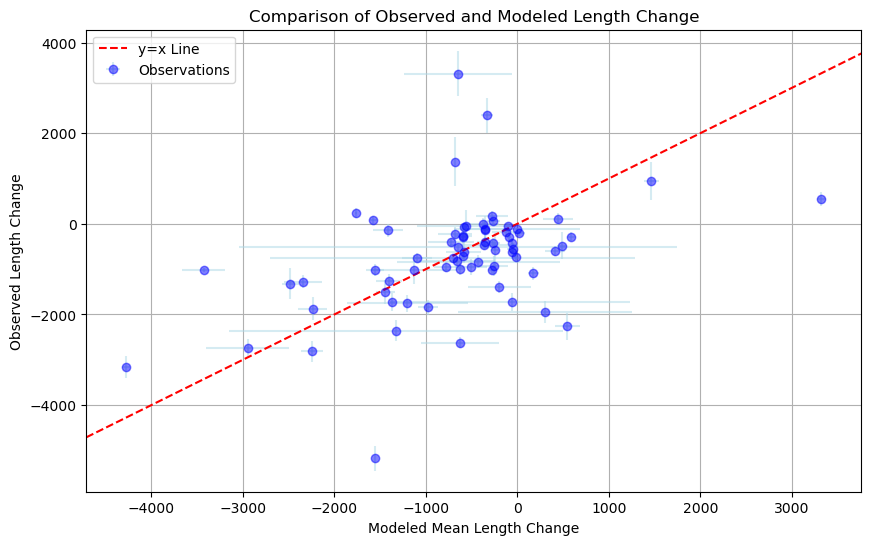

In [141]:
import pandas as pd

# Convert length_change and length_change_unc to numeric
length_change_obs_20002020['length_change'] = pd.to_numeric(length_change_obs_20002020['length_change'], errors='coerce')
length_change_obs_20002020['length_change_unc'] = pd.to_numeric(length_change_obs_20002020['length_change_unc'], errors='coerce')

# Check if there are any NaN values
print(length_change_obs_20002020.isna().sum())

# Handle NaNs (Option 1: drop them)
length_change_obs_20002020 = length_change_obs_20002020.dropna(subset=['length_change', 'length_change_unc'])

# Alternatively, Option 2: fill NaNs with 0 or another appropriate value
# length_change_obs_20002020 = length_change_obs_20002020.fillna(0)

# Now you can proceed to merge and plot
merged_df = pd.merge(length_change_obs_20002020, sum_0020_dL_SQ_m, left_on='rgiid', right_on='rgiid')

# Check the converted DataFrame
print(merged_df[['rgiid', 'length_change', 'length_change_unc', 'mean', 'std']].head())

# Proceed with the plotting
plt.figure(figsize=(10, 6))
plt.errorbar(merged_df['mean'], merged_df['length_change'], 
             xerr=merged_df['std'], yerr=merged_df['length_change_unc'], 
             fmt='o', label='Observations', color='blue', ecolor='lightblue', alpha=0.5)

plt.title('Comparison of Observed and Modeled Length Change')
plt.xlabel('Modeled Mean Length Change')
plt.ylabel('Observed Length Change')
plt.axline((0, 0), slope=1, color='red', linestyle='--', label='y=x Line')
plt.legend()
plt.grid()
plt.show()


In [142]:
length_change_obs_20002020

,rgiid,length_change,length_change_unc
0,7.00025,-1847.202592,155.703562
1,7.00026,1370.980536,545.419747
2,7.00027,3315.900062,502.835242
3,7.00029,-700.519754,82.051688
4,7.00031,-278.901942,277.355644
...,...,...,...
66,7.01506,-5171.482296,277.344353
67,7.01507,-1725.465684,198.045760
68,7.01559,-2750.890628,215.289396
69,7.01560,-3160.279541,241.112403


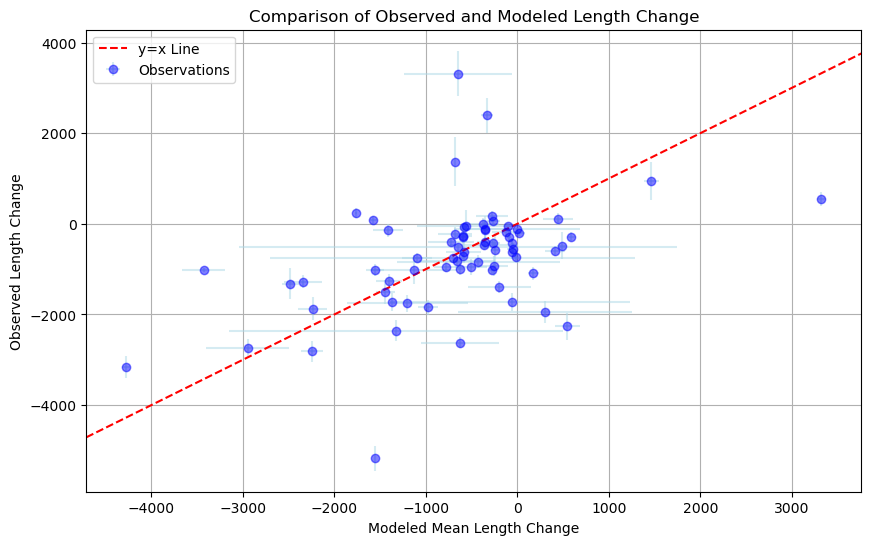

In [143]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df_obs and df_model are your DataFrames
# Merge the observed and modeled results on RGIId
merged_df = pd.merge(length_change_obs_20002020, sum_0020_dL_SQ_m, left_on='rgiid', right_on='rgiid')

plt.figure(figsize=(10, 6))
plt.errorbar(merged_df['mean'], merged_df['length_change'], 
             xerr=merged_df['std'], yerr=merged_df['length_change_unc'], 
             fmt='o', label='Observations', color='blue', ecolor='lightblue', alpha=0.5)

plt.title('Comparison of Observed and Modeled Length Change')
plt.xlabel('Modeled Mean Length Change')
plt.ylabel('Observed Length Change')
plt.axline((0, 0), slope=1, color='red', linestyle='--', label='y=x Line')
plt.legend()
plt.grid()
plt.show()


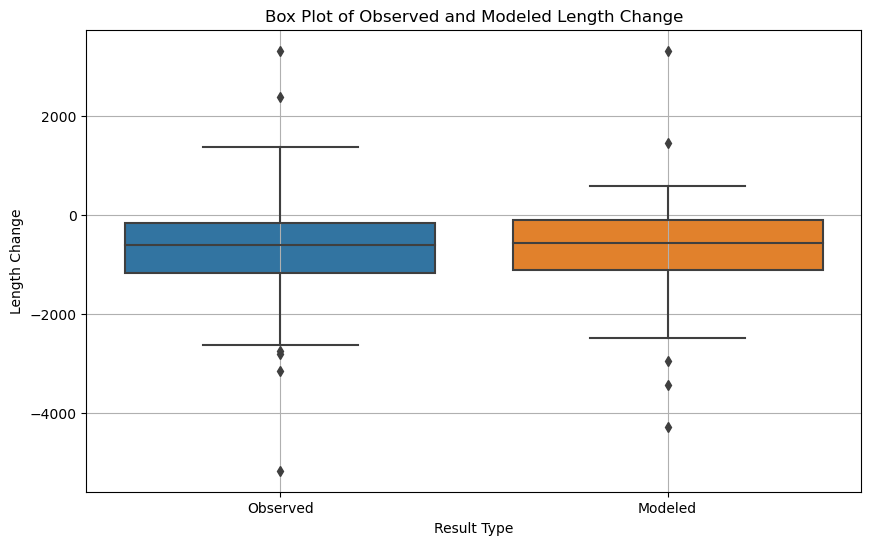

In [144]:
import seaborn as sns

# Prepare data for box plot
box_plot_data = pd.DataFrame({
    'Result Type': ['Observed']*len(length_change_obs_20002020) + ['Modeled']*len(sum_0020_dL_SQ_m),
    'Length Change': pd.concat([length_change_obs_20002020['length_change'], sum_0020_dL_SQ_m['mean']])
})

plt.figure(figsize=(10, 6))
sns.boxplot(x='Result Type', y='Length Change', data=box_plot_data)
plt.title('Box Plot of Observed and Modeled Length Change')
plt.grid()
plt.show()


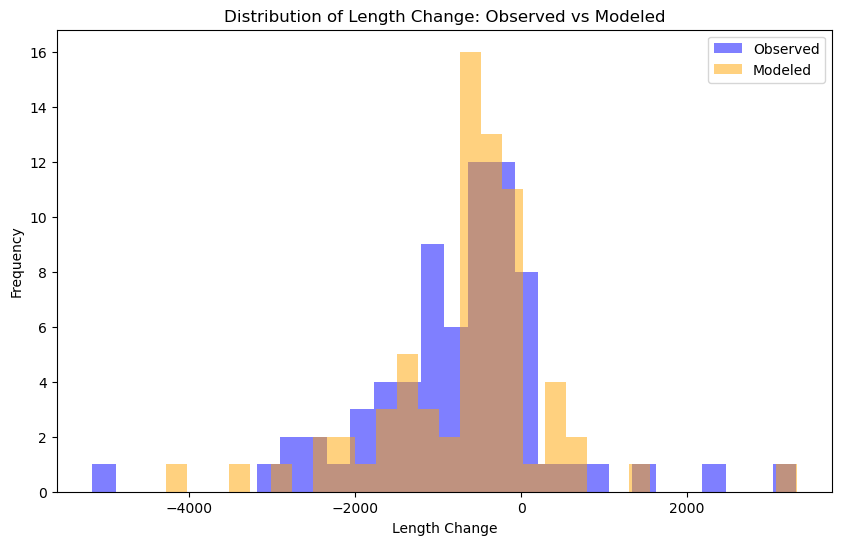

In [145]:
plt.figure(figsize=(10, 6))
plt.hist(length_change_obs_20002020['length_change'], bins=30, alpha=0.5, label='Observed', color='blue')
plt.hist(sum_0020_dL_SQ_m['mean'], bins=30, alpha=0.5, label='Modeled', color='orange')
plt.title('Distribution of Length Change: Observed vs Modeled')
plt.xlabel('Length Change')
plt.ylabel('Frequency')
plt.legend()
plt.show()


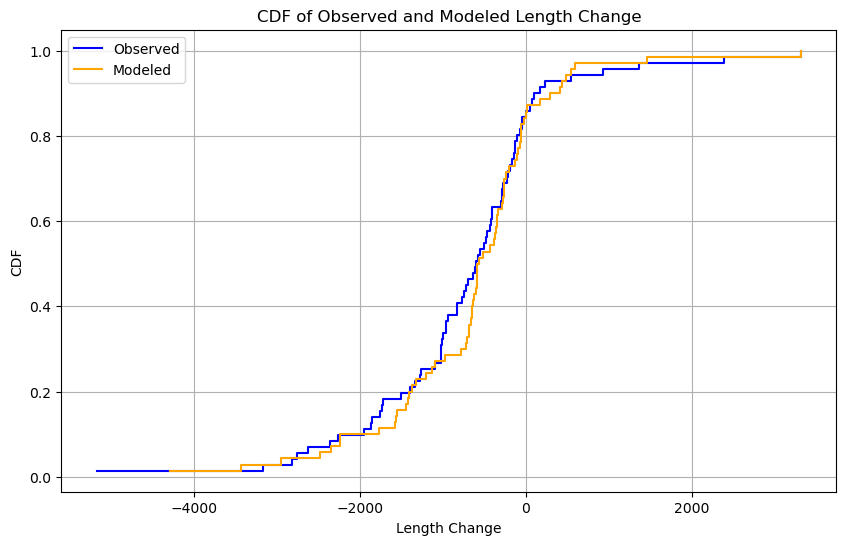

In [146]:
import numpy as np

# CDF Function
def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(data) + 1) / len(data)
    return x, y

x_obs, y_obs = ecdf(length_change_obs_20002020['length_change'])
x_model, y_model = ecdf(sum_0020_dL_SQ_m['mean'])

plt.figure(figsize=(10, 6))
plt.step(x_obs, y_obs, label='Observed', where='post', color='blue')
plt.step(x_model, y_model, label='Modeled', where='post', color='orange')
plt.title('CDF of Observed and Modeled Length Change')
plt.xlabel('Length Change')
plt.ylabel('CDF')
plt.legend()
plt.grid()
plt.show()


In [147]:
# Extracting lengths
observed_length_change = length_change_obs_20002020['length_change'].values
modeled_length_change = sum_0020_dL_SQ_m['mean'].values

# Print lengths for debugging
print("Length of observed data:", len(observed_length_change))
print("Length of modeled data:", len(modeled_length_change))


Length of observed data: 71
Length of modeled data: 70


In [148]:
# Display the RGIId values to identify potential missing ones
print("Observed RGIId values:", length_change_obs_20002020['rgiid'].unique())
print("Modeled RGIId values:", sum_0020_dL_SQ_m['rgiid'].unique())

# Finding RGIIds that are in observed but not in modeled
missing_in_modeled = set(length_change_obs_20002020['rgiid']) - set(sum_0020_dL_SQ_m['rgiid'])
print("RGIId values in observed but not in modeled:", missing_in_modeled)


Observed RGIId values: ['7.00025' '7.00026' '7.00027' '7.00029' '7.00031' '7.00036' '7.00042'
 '7.00060' '7.00061' '7.00064' '7.00224' '7.00250' '7.00251' '7.00276'
 '7.00277' '7.00301' '7.00315' '7.00425' '7.00448' '7.00463' '7.00464'
 '7.00465' '7.00468' '7.00470' '7.00471' '7.00474' '7.00502' '7.00551'
 '7.00552' '7.00558' '7.00645' '7.00659' '7.00681' '7.00682' '7.00714'
 '7.00715' '7.00724' '7.00727' '7.00733' '7.00789' '7.00790' '7.00791'
 '7.00794' '7.00832' '7.00854' '7.00859' '7.00874' '7.00883' '7.00892'
 '7.00896' '7.00903' '7.00910' '7.00945' '7.01328' '7.01353' '7.01449'
 '7.01458' '7.01464' '7.01487' '7.01488' '7.01492' '7.01493' '7.01494'
 '7.01499' '7.01500' '7.01503' '7.01506' '7.01507' '7.01559' '7.01560'
 '7.01561']
Modeled RGIId values: ['7.00025' '7.00026' '7.00027' '7.00029' '7.00031' '7.00036' '7.00042'
 '7.00060' '7.00061' '7.00064' '7.00224' '7.00250' '7.00251' '7.00276'
 '7.00301' '7.00315' '7.00425' '7.00448' '7.00463' '7.00464' '7.00465'
 '7.00468' '7.00470'

In [149]:
# Merge the two DataFrames
merged_df = pd.merge(length_change_obs_20002020, sum_0020_dL_SQ_m, left_on='rgiid', right_on='rgiid', how='inner')

# Check the length of the merged DataFrame
print("Length of merged data:", len(merged_df))
print("Merged DataFrame head:")
print(merged_df.head())


Length of merged data: 70
Merged DataFrame head:
     rgiid  length_change  length_change_unc        mean      median  \
0  7.00025   -1847.202592         155.703562 -977.320963 -945.689620   
1  7.00026    1370.980536         545.419747 -686.094056 -686.263534   
2  7.00027    3315.900062         502.835242 -647.545754 -808.226718   
3  7.00029    -700.519754          82.051688 -595.239904 -594.185908   
4  7.00031    -278.901942         277.355644 -589.901812 -589.691134   

          std  percent_2.5  percent_25  percent_75  percent_97.5         mad  \
0  109.550492 -1198.149922 -997.047761 -945.689620   -806.472076   76.614166   
1    0.889901  -686.263534 -686.263534 -686.263534   -681.421322    0.327091   
2  591.103754 -1672.224197 -808.226718 -100.387035   -100.387035  505.674029   
3    8.387954  -608.094668 -601.020250 -589.563040   -575.232651    6.825217   
4   89.419880  -738.296748 -678.498312 -537.389724   -391.075993   69.466740   

    hdi_95_low  hdi_95_high  
0 -1198

In [151]:
print("Type of modeled_df_raw:", type(sum_dL_SQ_0020_raw_m))
print("Content of modeled_df_raw:", sum_dL_SQ_0020_raw_m)


Type of modeled_df_raw: <class 'pandas.core.frame.DataFrame'>
Content of modeled_df_raw:       rgiid           lengthchange_dLdt_model_array_annual_myr
0   7.00025  [-945.6896201837741, -945.6896201837741, -945....
1   7.00026  [-681.4213219907612, -681.4213219907612, -681....
2   7.00027  [-100.38703465436319, -100.38703465436319, -10...
3   7.00029  [-591.3072444296639, -585.8112542240126, -573....
4   7.00031  [-510.2612531445993, -628.6624857416632, -628....
..      ...                                                ...
65  7.01506  [-1553.6003333622054, -1553.6003333622054, -15...
66  7.01507  [-1344.7485114805895, -1316.190790288359, -137...
67  7.01559  [-2376.5705910865604, -3271.399078786651, -327...
68  7.01560  [-4238.0674415938165, -4182.952130623727, -418...
69  7.01561  [3.61932696244033, 36.88966652620822, -48.0243...

[70 rows x 2 columns]


In [152]:
sum_dL_SQ_0020_raw_m

,rgiid,lengthchange_dLdt_model_array_annual_myr
0,7.00025,"[-945.6896201837741, -945.6896201837741, -945...."
1,7.00026,"[-681.4213219907612, -681.4213219907612, -681...."
2,7.00027,"[-100.38703465436319, -100.38703465436319, -10..."
3,7.00029,"[-591.3072444296639, -585.8112542240126, -573...."
4,7.00031,"[-510.2612531445993, -628.6624857416632, -628...."
...,...,...
65,7.01506,"[-1553.6003333622054, -1553.6003333622054, -15..."
66,7.01507,"[-1344.7485114805895, -1316.190790288359, -137..."
67,7.01559,"[-2376.5705910865604, -3271.399078786651, -327..."
68,7.01560,"[-4238.0674415938165, -4182.952130623727, -418..."


In [153]:
mb_obs_20102020_mwea

,rgiid,mb_clim_mwea,mb_clim_mwea_err
0,7.00025,0.323010,0.281602
1,7.00026,3.073486,0.540514
2,7.00027,2.645394,0.273213
3,7.00029,0.387519,0.175225
4,7.00031,0.464452,0.197022
...,...,...,...
66,7.01506,-0.186847,0.221493
67,7.01507,-0.259045,0.208095
68,7.01559,0.260823,0.100037
69,7.01560,0.032879,0.162608


In [154]:
mean_1020_mb_clim_mwea

,mean,median,std,percent_2.5,percent_25,percent_75,percent_97.5,mad,hdi_95_low,hdi_95_high,rgiid
0,0.760581,0.697801,1.247970e-01,0.638739,0.697801,0.790669,1.017695,1.045408e-01,0.638739,1.017695,7.00025
1,0.361401,0.359331,1.087121e-02,0.359331,0.359331,0.359331,0.418485,3.995817e-03,0.359331,0.359331,7.00026
2,1.403184,1.354607,1.376460e-01,1.175412,1.354607,1.523298,1.636347,1.208913e-01,1.175412,1.523298,7.00027
3,0.613816,0.609184,1.533840e-02,0.587855,0.607231,0.626732,0.644288,1.258074e-02,0.587855,0.639732,7.00029
4,0.554747,0.507136,1.265623e-01,0.394709,0.441710,0.675505,0.816216,1.085581e-01,0.394409,0.780567,7.00031
...,...,...,...,...,...,...,...,...,...,...,...
65,1.141376,1.141376,2.220446e-16,1.141376,1.141376,1.141376,1.141376,2.220446e-16,1.141376,1.141376,7.01506
66,1.084590,1.103164,1.116136e-01,0.894637,1.039733,1.151017,1.289098,8.528094e-02,0.894637,1.263553,7.01507
67,0.439860,0.433175,9.313975e-03,0.433175,0.433175,0.452835,0.452835,8.824219e-03,0.433175,0.452835,7.01559
68,0.587217,0.586614,3.291908e-02,0.522201,0.564177,0.602661,0.639511,2.512374e-02,0.522201,0.637080,7.01560


In [155]:
mean_MB_clim_1020_raw_mwe

,rgiid,massbalclim_TMS_model_array_annual_mwea
0,7.00025,"[0.6978009870206248, 0.6978009870206248, 0.697..."
1,7.00026,"[0.4184845167887259, 0.4184845167887259, 0.418..."
2,7.00027,"[1.5232976366518098, 1.5232976366518098, 1.523..."
3,7.00029,"[0.6413577000144799, 0.6325334963072253, 0.639..."
4,7.00031,"[0.3684648254313064, 0.643993639360465, 0.6439..."
...,...,...
65,7.01506,"[1.141375649706378, 1.141375649706378, 1.14137..."
66,7.01507,"[1.3232948990693476, 1.0870348115331645, 1.177..."
67,7.01559,"[0.45295730022960423, 0.43317486652276554, 0.4..."
68,7.01560,"[0.6779334081484784, 0.6390945680020769, 0.639..."


In [156]:
length_change_obs_20002010

,rgiid,length_change,length_change_unc
0,7.00025,-916.455491,98.030607
1,7.00026,-372.851935,174.263373
2,7.00027,1718.712681,98.030607
3,7.00029,-358.287601,4.936828
4,7.00031,-389.613369,167.436647
...,...,...,...
66,7.01506,-2145.707731,100.409538
67,7.01507,-646.288718,143.739318
68,7.01559,-1304.095678,107.886713
69,7.01560,-1197.078121,76.710583


In [128]:
from matplotlib.gridspec import GridSpec
def plot_cdf_and_one_to_one(observed_df = None, modeled_df = None, modeled_df_raw= None,
                            obs_name = None, obs_unc_name = None, modeled_key = None, item_name = None,
                            period = None, Xlabel = None, Ylabel = None,Xlim = None, Ylim = None,
                            subplot_label_L = 'a', subplot_label_R = 'b',title= None, save_path=None, save_name=None,legend_index = True):
    """
    Plots the CDF for observed and modeled values,
    and a one-to-one comparison with box plots for modeled results and error bars for observations.
    Parameters:
    - observed_df (pd.DataFrame): DataFrame containing observed values with columns e.g. 'rgiid', 'length_change', 'length_change_unc'.
    - modeled_df (pd.DataFrame): DataFrame containing modeled values with columns 'rgiid', 'mean', 'hdi_95_low', 'hdi_95_high'.
    - modeled_df_raw (pd.DataFrame): DataFrame containing raw modeled values for box plots, with 'rgiid' and 'lengthchange_dLdt_model_array_annual_myr' columns.
    - obs_name (str): Name of the observed length change column in observed_df, e.g. 'length_change'.
    - obs_unc_name (str): Name of the observed length change uncertainty column in observed_df, e.g. 'length_change_unc'.
    - modeled_key (str): Key for the modeled values in modeled_df, e.g. 'lengthchange_dLdt_model_array_annual_myr'.
    - item_name (str): Name of the item to be compare, e.g. 'Length Change'.
    - period (str): Period for the data, e.g. '2000-2010'.
    - Xlabel (str): Label for the x-axis. e.g. 'Length Change (m, observed)', 'Climatic Mass Balance (m w.e. a$^{-1}$, observed)'.
    - Ylabel (str): Label for the y-axis. e.g. 'Length Change (m, modeled)', 'Climatic Mass Balance (m w.e. a$^{-1}$, modeled)''.
    - Xlim (tuple): Limits for the x-axis, e.g. (0, 1000).
    - Ylim (tuple): Limits for the y-axis, e.g. (0, 1000).
    - subplot_label_L (str): Label for the left subplot, e.g. 'a)'.
    - subplot_label_R (str): Label for the right subplot, e.g. 'b)'.
    - title (str): Title for the plot.
    - save_path (str): Path to save the plot.
    - save_name (str): Name to save the plot file.
    """
    # Merge DataFrames
    merged_df = pd.merge(observed_df, modeled_df, left_on='rgiid', right_on='rgiid', how='inner')

    # Extract data
    # scale the length change from m to km
    if obs_name == 'length_change':
        scale_v = 0.001  # Changed from 0.0001 to properly convert m to km
    else:
        scale_v = 1
    obs_change = merged_df[obs_name].values * scale_v
    obs_unc = merged_df[obs_unc_name].values * scale_v
    model_mean = merged_df['mean'].values * scale_v
    hdi_low, hdi_high = merged_df['hdi_95_low'].values * scale_v, merged_df['hdi_95_high'].values * scale_v

    # Create figure with proper layout management
    fig = plt.figure(figsize=(10, 5), constrained_layout=True)
    #fig.suptitle(title, fontsize=18, y=1.02)

    # Create gridspec with adjusted margins
    gs = GridSpec(1, 2, figure=fig, width_ratios=[1, 1], height_ratios=[1], wspace=0.17, 
                  left=0.04, right=0.86, bottom=0.15, top=0.9)

    # --- One-to-One Plot with Boxplots (left subplot) ---
    ax1 = fig.add_subplot(gs[0])

    # Create boxplot data for each RGI ID using ensemble results
    box_data = []
    for _, row in modeled_df_raw.iterrows():
        # Convert string representation to numpy array if needed
        if isinstance(row[modeled_key], str):
            # More robust string to array conversion
            ensemble_members = np.array([float(x) for x in row[modeled_key].strip('[]').split()]) * scale_v
        else:
            ensemble_members = np.array(row[modeled_key]) * scale_v
        box_data.append(ensemble_members)  # THIS WAS MISSING IN ORIGINAL CODE

    # Calculate default limits if not provided
    if Xlim is None:
        all_box_values = np.concatenate(box_data)
        Xlim = (min(obs_change.min(), all_box_values.min()), 
                max(obs_change.max(), all_box_values.max()))
    if Ylim is None:
        Ylim = Xlim  # Use same limits for y-axis

    # Position boxes at observed value positions
    box_positions = obs_change
    box_widths = 0.05 * (Xlim[1] - Xlim[0])  # 5% of total x-range

    boxprops = dict(facecolor='orange', alpha=0.3, edgecolor='orange', linewidth=1.5)
    whiskerprops = dict(color='orange', alpha=0.8)
    medianprops = dict(color='orange', linewidth=1.5)
    capprops = dict(color='orange', linewidth=1.5)

    # Ensure we have matching lengths
    if len(box_data) != len(box_positions):
        raise ValueError(f"Length mismatch: box_data ({len(box_data)}) != box_positions ({len(box_positions)})")

    ax1.boxplot(box_data,
               positions=box_positions,
               widths=box_widths,
               patch_artist=True,
               boxprops=boxprops,
               whiskerprops=whiskerprops,
               medianprops=medianprops,
               capprops=capprops,
               showfliers=False,
               manage_ticks=False)

    # Create a proxy artist for the boxplot in the legend
    box_legend = plt.Line2D([0], [0], color='orange', alpha=0.3, lw=5, label='Modeled')

    # Plot values with error bars
    ax1.errorbar(obs_change, model_mean,
               xerr=obs_unc, markersize=4,
               fmt='o', color='blue', alpha=0.7,
               label='Observed', capsize=3)

    # Plot 1:1 line
    ax1.plot(Xlim, Xlim, 'k--', label='1:1 Line')

    # Configure plot
    ax1.set(xlabel=Xlabel,
           ylabel=Ylabel,
           aspect='equal',
           xlim=Xlim,
           ylim=Ylim)
    #ax1.legend(handles=ax1.get_legend_handles_labels()[0] + [box_legend])
    ax1.grid(linestyle='--')
    #set the legend
    if legend_index:
        # If legend_index is True, show the legend including existing handles and box_legend
        handles = ax1.get_legend_handles_labels()[0] + [box_legend]
        ax1.legend(handles=handles, frameon=False)  # Show legend without box edge
    else:
        # If legend_index is False, do not show the legend at all
        ax1.legend().set_visible(False)  # This effectively hides the legend
    # Add 'a)' label outside top-left
    ax1.annotate(subplot_label_L, xy=(-0.13, 0.96), xycoords='axes fraction',
                fontsize=18, weight='normal', ha='left', va='bottom',
                bbox=dict(facecolor='white', edgecolor='none', pad=0))
    # --- CDF Plot (right subplot) ---
    ax2 = fig.add_subplot(gs[1])
    
    # Plot observed CDF and uncertainty
    sns.ecdfplot(obs_change, ax=ax2, label='Observed', color='blue')
    
    # Calculate and plot observed uncertainty band
    lower_obs = obs_change - obs_unc
    upper_obs = obs_change + obs_unc
    x_obs = np.linspace(lower_obs.min(), upper_obs.max(), 1000)
    cdf_lower = np.searchsorted(np.sort(lower_obs), x_obs, side='right') / len(lower_obs)
    cdf_upper = np.searchsorted(np.sort(upper_obs), x_obs, side='right') / len(upper_obs)
    ax2.fill_between(x_obs, cdf_lower, cdf_upper, color='blue', alpha=0.3, label='Observed Uncertainty')
    
    # Plot modeled CDF and HDI
    sns.ecdfplot(model_mean, ax=ax2, label='Modeled Mean', color='orange')
    x_model = np.linspace(hdi_low.min(), hdi_high.max(), 1000)
    cdf_hdi_low = np.searchsorted(np.sort(hdi_low), x_model, side='right') / len(hdi_low)
    cdf_hdi_high = np.searchsorted(np.sort(hdi_high), x_model, side='right') / len(hdi_high)
    ax2.fill_between(x_model, cdf_hdi_low, cdf_hdi_high, color='orange', alpha=0.3, label='HDI 95%')

    ax2.set(xlabel=item_name,
           ylabel='Cumulative Probability',
           xlim = Xlim)

    ax2.grid(linestyle='--')
    #set the legend
    if legend_index:
        # If legend_index is True, show the legend including existing handles
        handles = ax2.get_legend_handles_labels()[0]
        ax2.legend(handles=handles, frameon=False)
    else:
        # If legend_index is False, do not show the legend at all
        ax2.legend().set_visible(False)
    # Add 'b)' label outside top-left
    ax2.annotate(subplot_label_R, xy=(-0.14, 0.96), xycoords='axes fraction',
                fontsize=18, weight='normal', ha='left', va='bottom',
                bbox=dict(facecolor='white', edgecolor='none', pad=0))
    # Adjust layout and save
    plt.tight_layout()
    # Save the figure
    if save_path is None:
        save_path = 'Regional_analysis/figures/'
    else:
        save_path = os.path.join(save_path, 'Regional_analysis', 'figures')
    os.makedirs(save_path, exist_ok=True)
    if save_name is None:
        save_name = 'cdf_and_one_to_one_comparison' + f'_{item_name.replace(" ", "_")}' + f'_{period.replace("-", "_")}'
    save_file = os.path.join(save_path, f"{save_name}.png")
    plt.savefig(save_file, bbox_inches='tight', dpi=300)
    print(f"Figure saved to {save_file}")

    plt.show()

/tmp/ipykernel_37772/2292744598.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_37772/2292744598.py:167: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Figure saved to /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Regional_analysis/figures/cdf_and_one_to_one_comparison_Climatic_mass_balance_(m_w.e._a$^{-1}$)_2010_2020.png


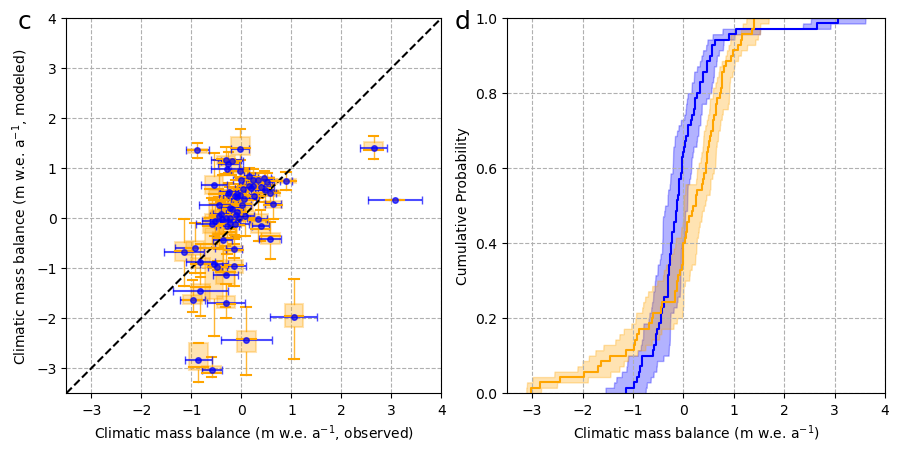

In [129]:
plot_cdf_and_one_to_one(observed_df = mb_obs_20102020_mwea, modeled_df = mean_1020_mb_clim_mwea, modeled_df_raw= mean_MB_clim_1020_raw_mwe,
                            obs_name = 'mb_clim_mwea' , obs_unc_name = 'mb_clim_mwea_err', modeled_key = 'massbalclim_TMS_model_array_annual_mwea', item_name = 'Climatic mass balance (m w.e. a$^{-1}$)',
                            period = '2010-2020',Xlabel = 'Climatic mass balance (m w.e. a$^{-1}$, observed)',Ylabel = 'Climatic mass balance (m w.e. a$^{-1}$, modeled)', Xlim = (-3.5,4), Ylim = (-3.5,4),
                            subplot_label_L ='c', subplot_label_R = 'd',title= None, save_path = postpro_output_fp_region, save_name=None,legend_index = False)

/tmp/ipykernel_37772/2292744598.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_37772/2292744598.py:167: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Figure saved to /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Regional_analysis/figures/cdf_and_one_to_one_comparison_Climatic_mass_balance_(m_w.e._a$^{-1}$)_2000_2010.png


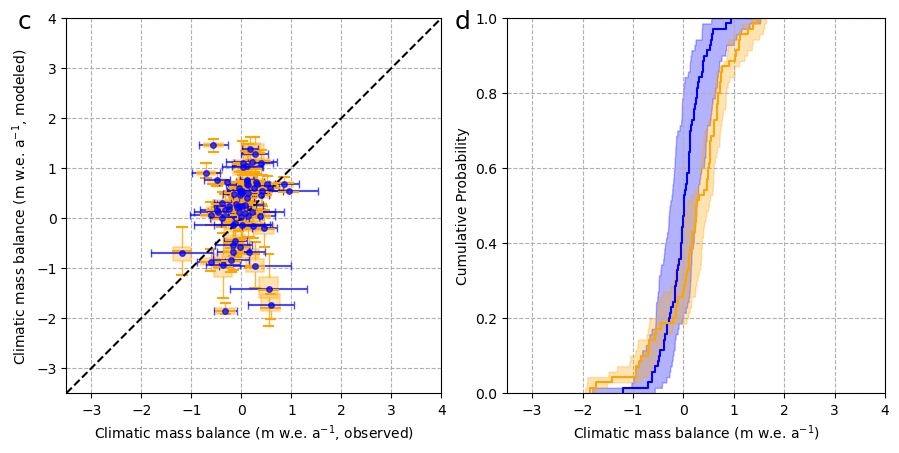

In [130]:
plot_cdf_and_one_to_one(observed_df = mb_obs_20002010_mwea, modeled_df = mean_0010_mb_clim_mwea, modeled_df_raw= mean_MB_clim_0010_raw_mwe,
                            obs_name = 'mb_clim_mwea' , obs_unc_name = 'mb_clim_mwea_err', modeled_key = 'massbalclim_TMS_model_array_annual_mwea', item_name = 'Climatic mass balance (m w.e. a$^{-1}$)',
                            period = '2000-2010',Xlabel = 'Climatic mass balance (m w.e. a$^{-1}$, observed)',Ylabel = 'Climatic mass balance (m w.e. a$^{-1}$, modeled)', Xlim = (-3.5,4), Ylim = (-3.5,4), 
                            subplot_label_L ='c', subplot_label_R = 'd',title= None, save_path = postpro_output_fp_region, save_name=None,legend_index = False)

/tmp/ipykernel_37772/2292744598.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_37772/2292744598.py:167: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Figure saved to /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Regional_analysis/figures/cdf_and_one_to_one_comparison_Climatic_mass_balance_(m_w.e._a$^{-1}$)_2000_2020.png


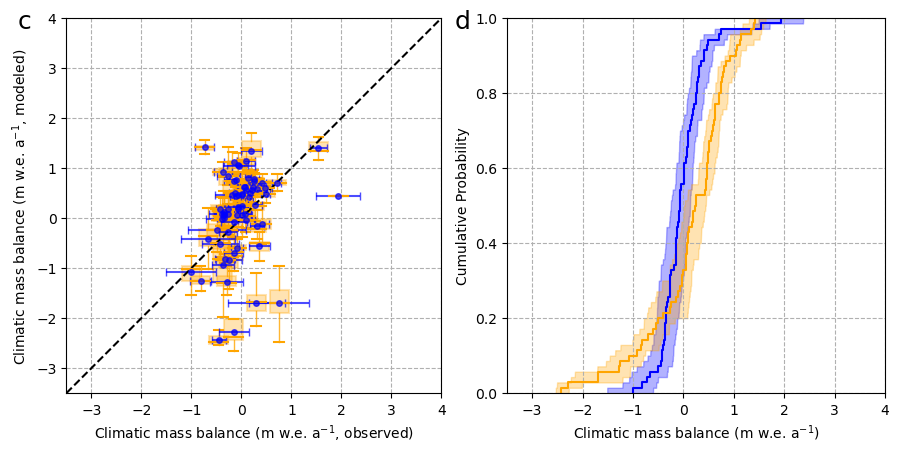

In [131]:
plot_cdf_and_one_to_one(observed_df = mb_obs_20002020_mwea, modeled_df = mean_0020_mb_clim_mwea, modeled_df_raw= mean_MB_clim_0020_raw_mwe,
                            obs_name = 'mb_clim_mwea' , obs_unc_name = 'mb_clim_mwea_err', modeled_key = 'massbalclim_TMS_model_array_annual_mwea', item_name = 'Climatic mass balance (m w.e. a$^{-1}$)',
                            period = '2000-2020',Xlabel = 'Climatic mass balance (m w.e. a$^{-1}$, observed)',Ylabel = 'Climatic mass balance (m w.e. a$^{-1}$, modeled)', Xlim = (-3.5,4), Ylim = (-3.5,4), 
                            subplot_label_L ='c', subplot_label_R = 'd',title= None, save_path = postpro_output_fp_region, save_name=None,legend_index = False)

/tmp/ipykernel_37772/2292744598.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_37772/2292744598.py:167: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Figure saved to /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Regional_analysis/figures/cdf_and_one_to_one_comparison_Length_change_(km)_2000_2010.png


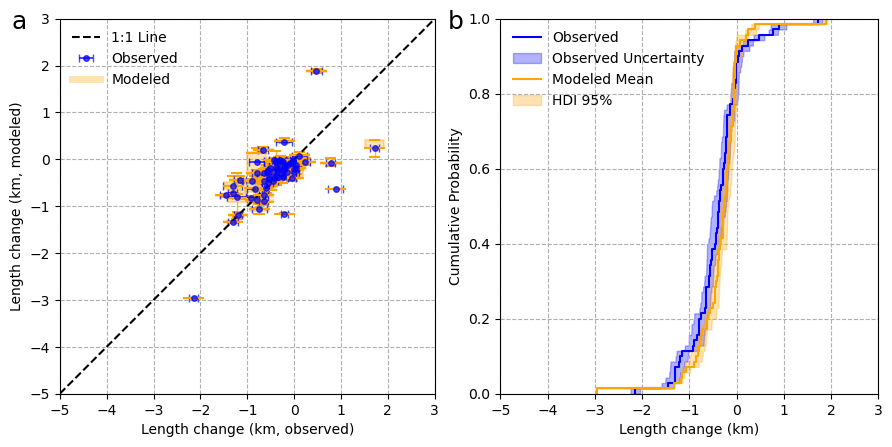

In [132]:
plot_cdf_and_one_to_one(observed_df = length_change_obs_20002010, modeled_df = sum_0010_dL_SQ_m, modeled_df_raw= sum_dL_SQ_0010_raw_m,
                            obs_name = 'length_change' , obs_unc_name = 'length_change_unc', modeled_key = 'lengthchange_dLdt_model_array_annual_myr', item_name = 'Length change (km)',
                            period = '2000-2010',Xlabel = 'Length change (km, observed)',Ylabel = 'Length change (km, modeled)', 
                        Xlim = (-5,3), Ylim = (-5,3),subplot_label_L ='a', subplot_label_R = 'b',title= None, save_path = postpro_output_fp_region, save_name=None)


/tmp/ipykernel_37772/2292744598.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_37772/2292744598.py:167: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Figure saved to /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Regional_analysis/figures/cdf_and_one_to_one_comparison_Length_change_(km)_2000_2020.png


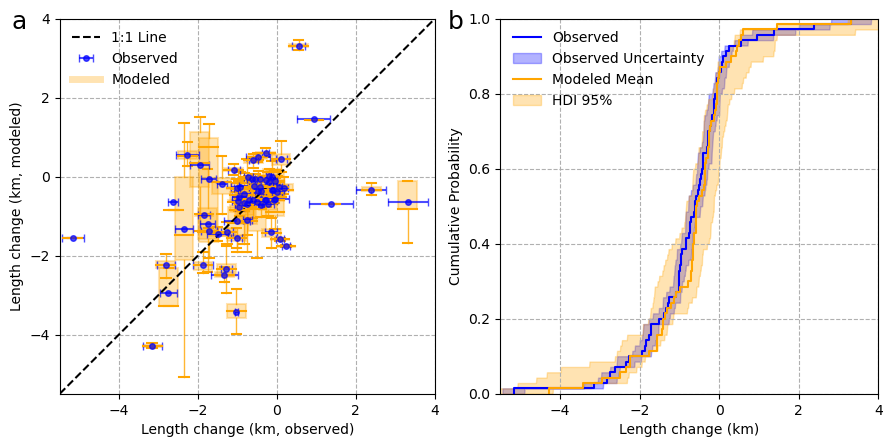

In [133]:
plot_cdf_and_one_to_one(observed_df = length_change_obs_20002020, modeled_df = sum_0020_dL_SQ_m, modeled_df_raw= sum_dL_SQ_0020_raw_m,
                            obs_name = 'length_change' , obs_unc_name = 'length_change_unc', modeled_key = 'lengthchange_dLdt_model_array_annual_myr', item_name = 'Length change (km)',
                            period = '2000-2020',Xlabel = 'Length change (km, observed)',Ylabel = 'Length change (km, modeled)', 
                        Xlim = (-5.5,4), Ylim = (-5.5,4),subplot_label_L ='a', subplot_label_R = 'b',title= None, save_path = postpro_output_fp_region, save_name=None)


/tmp/ipykernel_37772/2292744598.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_37772/2292744598.py:167: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Figure saved to /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Regional_analysis/figures/cdf_and_one_to_one_comparison_Length_change_(km)_2010_2020.png


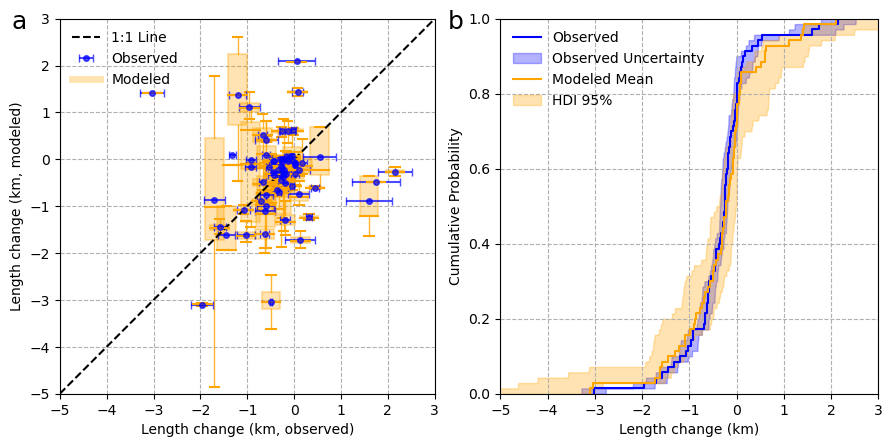

In [134]:
plot_cdf_and_one_to_one(observed_df = length_change_obs_20102020, modeled_df = sum_1020_dL_SQ_m, modeled_df_raw= sum_dL_SQ_1020_raw_m,
                            obs_name = 'length_change' , obs_unc_name = 'length_change_unc', modeled_key = 'lengthchange_dLdt_model_array_annual_myr', item_name = 'Length change (km)',
                            period = '2010-2020',Xlabel = 'Length change (km, observed)',Ylabel = 'Length change (km, modeled)', 
                        Xlim = (-5,3), Ylim = (-5,3),subplot_label_L ='a', subplot_label_R = 'b',title= None, save_path = postpro_output_fp_region, save_name=None)


In [135]:
fa_obs_20002010_gta

,rgiid,fa_gta_obs,fa_gta_obs_unc
0,7.00025,0.279969,0.185576
1,7.00026,0.217811,0.087079
2,7.00027,0.392955,0.095748
3,7.00029,0.230259,0.083178
4,7.00031,0.071267,0.042821
...,...,...,...
66,7.01506,0.343641,0.081292
67,7.01507,0.038798,0.018498
68,7.01559,0.079105,0.066933
69,7.01560,0.135165,0.069448


In [136]:
mean_1020_FA_Gta

,mean,median,std,percent_2.5,percent_25,percent_75,percent_97.5,mad,hdi_95_low,hdi_95_high,rgiid
0,0.466214,0.379233,1.212541e-01,0.379233,0.379233,0.576782,0.750948,1.042062e-01,0.379233,0.672510,7.00025
1,0.186883,0.186526,1.874548e-03,0.186526,0.186526,0.186526,0.196726,6.890078e-04,0.186526,0.186526,7.00026
2,1.396613,1.374345,2.696984e-02,1.369544,1.369544,1.422969,1.448177,2.655034e-02,1.369544,1.422969,7.00027
3,0.132501,0.132635,1.144966e-03,0.130397,0.131815,0.133205,0.135205,8.530766e-04,0.130016,0.134159,7.00029
4,0.074093,0.073199,5.218942e-03,0.066072,0.070792,0.077736,0.086569,3.988934e-03,0.065652,0.084412,7.00031
...,...,...,...,...,...,...,...,...,...,...,...
65,0.853774,0.853774,1.110223e-16,0.853774,0.853774,0.853774,0.853774,1.110223e-16,0.853774,0.853774,7.01506
66,0.166770,0.164744,6.792584e-03,0.155161,0.161903,0.172270,0.179556,5.889867e-03,0.154608,0.177171,7.01507
67,0.490440,0.518199,3.870891e-02,0.436895,0.436895,0.518199,0.518199,3.664139e-02,0.436895,0.518199,7.01559
68,1.611952,1.613945,2.091819e-02,1.572549,1.598476,1.628844,1.642210,1.664407e-02,1.570596,1.638071,7.01560


In [137]:
mean_1020_FA_raw_Gta

,rgiid,calving_flux_Gta_TMS_model_array_annual
0,7.00025,"[0.37923328198081946, 0.37923328198081946, 0.3..."
1,7.00026,"[0.19672593530979438, 0.19672593530979438, 0.1..."
2,7.00027,"[1.4229687343925996, 1.4229687343925996, 1.422..."
3,7.00029,"[0.13304084878569716, 0.13146159026905987, 0.1..."
4,7.00031,"[0.0679366438456919, 0.07617010863649429, 0.07..."
...,...,...
65,7.01506,"[0.8537744864726106, 0.8537744864726106, 0.853..."
66,7.01507,"[0.17292313632290232, 0.15616897674987967, 0.1..."
67,7.01559,"[0.41382199268682046, 0.5181990075856532, 0.51..."
68,7.01560,"[1.658024139144271, 1.6260058977628187, 1.6260..."


/tmp/ipykernel_37772/2292744598.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_37772/2292744598.py:167: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Figure saved to /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Regional_analysis/figures/cdf_and_one_to_one_comparison_Frontal_ablation_(Gt_a$^{-1}$)_2000_2010.png


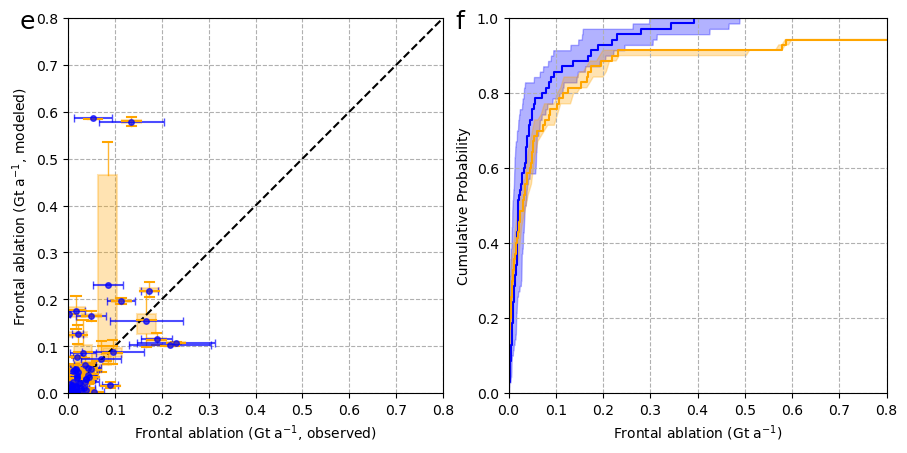

In [138]:
plot_cdf_and_one_to_one(observed_df = fa_obs_20002010_gta, modeled_df = mean_0010_FA_Gta, modeled_df_raw= mean_0010_FA_raw_Gta,
                            obs_name = 'fa_gta_obs' , obs_unc_name = 'fa_gta_obs_unc', modeled_key = 'calving_flux_Gta_TMS_model_array_annual', item_name = 'Frontal ablation (Gt a$^{-1}$)',
                            period = '2000-2010',Xlabel = 'Frontal ablation (Gt a$^{-1}$, observed)',Ylabel = 'Frontal ablation (Gt a$^{-1}$, modeled)', 
                        Xlim = (0,0.8), Ylim = (0,0.8),subplot_label_L ='e', subplot_label_R = 'f',title= None, save_path = postpro_output_fp_region, save_name=None,legend_index = False)


/tmp/ipykernel_37772/2292744598.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_37772/2292744598.py:167: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Figure saved to /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Regional_analysis/figures/cdf_and_one_to_one_comparison_Frontal_ablation_(Gt_a$^{-1}$)_2000_2020.png


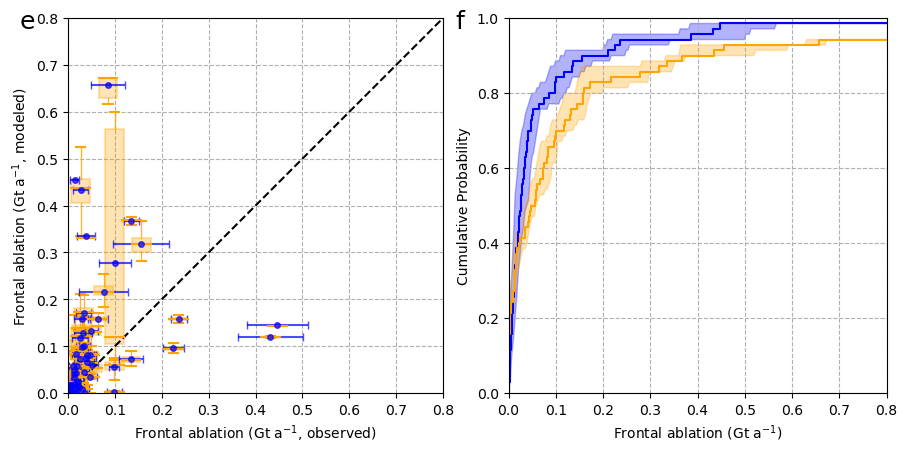

In [139]:
plot_cdf_and_one_to_one(observed_df = fa_obs_20002020_gta, modeled_df = mean_0020_FA_Gta, modeled_df_raw= mean_0020_FA_raw_Gta,
                            obs_name = 'fa_gta_obs' , obs_unc_name = 'fa_gta_obs_unc', modeled_key = 'calving_flux_Gta_TMS_model_array_annual', item_name = 'Frontal ablation (Gt a$^{-1}$)',
                            period = '2000-2020',Xlabel = 'Frontal ablation (Gt a$^{-1}$, observed)',Ylabel = 'Frontal ablation (Gt a$^{-1}$, modeled)', 
                        Xlim = (0,0.8), Ylim = (0,0.8),subplot_label_L ='e', subplot_label_R = 'f',title= None, save_path = postpro_output_fp_region, save_name=None,legend_index = False)


/tmp/ipykernel_37772/2292744598.py:167: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_37772/2292744598.py:167: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Figure saved to /home/ruitang/Astra_UIO_Ruitang/SermeQ_PyGEM_OGGM/Output/Calibration/modeloutput/../Postprocessing/07/Regional_analysis/figures/cdf_and_one_to_one_comparison_Frontal_ablation_(Gt_a$^{-1}$)_2010_2020.png


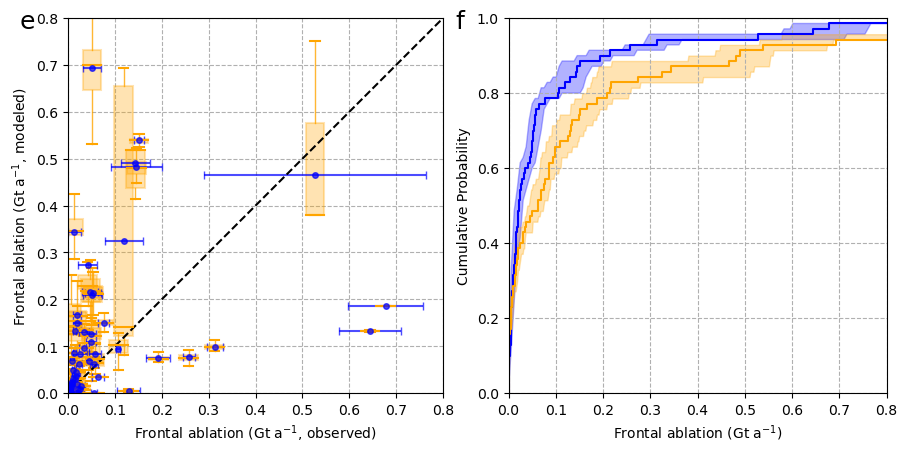

In [140]:
plot_cdf_and_one_to_one(observed_df = fa_obs_20102020_gta, modeled_df = mean_1020_FA_Gta, modeled_df_raw= mean_1020_FA_raw_Gta,
                            obs_name = 'fa_gta_obs' , obs_unc_name = 'fa_gta_obs_unc', modeled_key = 'calving_flux_Gta_TMS_model_array_annual', item_name = 'Frontal ablation (Gt a$^{-1}$)',
                            period = '2010-2020',Xlabel = 'Frontal ablation (Gt a$^{-1}$, observed)',Ylabel = 'Frontal ablation (Gt a$^{-1}$, modeled)', 
                        Xlim = (0,0.8), Ylim = (0,0.8),subplot_label_L ='e', subplot_label_R = 'f',title= None, save_path = postpro_output_fp_region, save_name=None,legend_index = False)
